In [2]:
pip install scikit-learn

   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
    --------------------------------------- 0.3/10.7 MB ? eta -:--:--
    --------------------------------------- 0.3/10.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.7 MB 508.0 kB/s eta 0:00:20
   - -------------------------------------- 0.5/10.7 MB 508.0 kB/s eta 0:00:20
   - -------------------------------------- 0.5/10.7 MB 508.0 kB/s eta 0:00:20
   -- ------------------------------------- 0.8/10.7 MB 500.8 kB/s eta 0:00:20
   -- ------------------------------------- 0.8/10.7 MB 500.8 kB/s eta 0:00:20
   -- ------------------------------------- 0.8/10.7 MB 500.8 kB/s eta 0:00:20
   --- ------------------------------------ 1.0/10.7 MB 457.5 kB/s eta 0:00:22
   --- ------------------------------------ 1.0/10.7 MB 457.5 kB/s eta 0:00:22
   --- ------------------------------------ 1.0/10.7 MB 457.5 kB/s eta 0:00:22
   --- --


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.model_selection as ms
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error
from sklearn import feature_selection as fs
import numpy.random as nr


In [2]:
#import the cleaned dataset from csv file
data = pd.read_csv('data_cleaned.csv')
data.head()

,country,year,cereal_yield,fdi_perc_gdp,en_per_gdp,en_per_cap,co2_ttl,co2_per_cap,co2_per_gdp,pop_urb_aggl_perc,prot_area_perc,gdp,gni_per_cap,under_5_mort_rate,pop_growth_perc,pop,urb_pop_growth_perc,urb_pop
0,AGO,1991,417.4,5.449515,179.271884,565.451027,4367.397,0.409949,129.971142,15.290728,12.399822,1.219375e+10,820.0,239.1,3.034866,10653515.0,6.687032,4.099473e+06
1,ARE,1991,1594.0,0.076475,245.977706,12262.388130,57010.849,29.851550,598.807980,26.377204,0.266886,3.391964e+10,19340.0,20.5,5.442852,1909812.0,5.265704,1.507988e+06
2,ARG,1991,2666.1,1.285579,173.122857,1434.960601,117021.304,3.536073,426.614517,39.119646,4.772468,1.897200e+11,3960.0,25.8,1.372593,33093579.0,1.762636,2.890393e+07
3,AUS,1991,1603.3,1.306912,208.686644,4926.727783,281530.258,16.288490,689.948873,60.356798,7.915273,3.299655e+11,18380.0,8.6,1.274577,17284000.0,1.438378,1.478473e+07
4,AUT,1991,5463.0,0.209142,128.939160,3381.073790,65888.656,8.448456,322.186648,19.746121,20.991143,1.721664e+11,21200.0,8.9,1.134999,7798899.0,1.134999,5.131676e+06


In [3]:
#define a random state number for all random state - ensure reproducibility of results
random_state_num = 0

In [4]:
print("Shape of the dataset: ", data.shape)

Shape of the dataset:  (1700, 18)


In [5]:
print("available columns in the dataset: ")
data.dtypes

available columns in the dataset: 


country                 object
year                     int64
cereal_yield           float64
fdi_perc_gdp           float64
en_per_gdp             float64
en_per_cap             float64
co2_ttl                float64
co2_per_cap            float64
co2_per_gdp            float64
pop_urb_aggl_perc      float64
prot_area_perc         float64
gdp                    float64
gni_per_cap            float64
under_5_mort_rate      float64
pop_growth_perc        float64
pop                    float64
urb_pop_growth_perc    float64
urb_pop                float64
dtype: object

In [6]:
#remove the ARE outliers from the dataset
data = data[data['country'] != 'ARE']

#print shape after removing outliers
print("Shape of the dataset after removing outliers: ")
data.shape

Shape of the dataset after removing outliers: 


(1686, 18)

In [7]:
#choose features and label columns
features_cols = ['cereal_yield', 'fdi_perc_gdp','gni_per_cap','en_per_cap',
            'pop_urb_aggl_perc','prot_area_perc','pop_growth_perc','urb_pop_growth_perc']
label_col = ['co2_per_cap']

#convert into numpy arrays (required for scikit-learn model)
features = np.array(data[features_cols])
label = np.array(data[label_col])

In [8]:
features

array([[4.17400000e+02, 5.44951458e+00, 8.20000000e+02, ...,
        1.23998220e+01, 3.03486601e+00, 6.68703163e+00],
       [2.66610000e+03, 1.28557882e+00, 3.96000000e+03, ...,
        4.77246763e+00, 1.37259322e+00, 1.76263616e+00],
       [1.60330000e+03, 1.30691206e+00, 1.83800000e+04, ...,
        7.91527300e+00, 1.27457750e+00, 1.43837778e+00],
       ...,
       [4.05530000e+03, 3.50366162e+00, 5.86000000e+03, ...,
        6.85955008e+00, 1.10405722e+00, 1.89744981e+00],
       [7.71500000e+02, 1.47989700e+01, 1.60000000e+02, ...,
        9.98656658e+00, 2.76328559e+00, 4.60583400e+00],
       [2.14400000e+03, 6.41099075e+00, 9.70000000e+02, ...,
        3.59830177e+01, 2.65395608e+00, 3.04999620e+00]], shape=(1686, 8))

In [9]:
# split the dataset into training and testing subsets
features_train, features_test, label_train, label_test = train_test_split(features,
                                                                           label,
                                                                           test_size=0.2, 
                                                                           random_state=random_state_num)

In [10]:
# set folds for cross-validation for feature selection
nr.seed(1)
feature_folds = ms.KFold(n_splits=10, shuffle=True, random_state=random_state_num) 

#Define the model
rf_selector = RandomForestRegressor(random_state=random_state_num)

# Define an object for a model for recursive feature elimination
nr.seed(1)
selector = fs.RFECV(estimator=rf_selector, step=1, cv=feature_folds, scoring='r2',n_jobs=-1)

selector = selector.fit(features_train, label_train)

selector.support_
print("feature ranking after RFECV:")
print(selector.ranking_)

# print the important features
ranks_transfrom = list(np.transpose(selector.ranking_))
choosen_features = [i for i, j in zip(features_cols, ranks_transfrom) if j == 1]
print("Chosen features: ")
print(choosen_features)

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1363: DataConvers

feature ranking after RFECV:
[1 3 1 1 1 1 1 2]
Chosen features: 
['cereal_yield', 'gni_per_cap', 'en_per_cap', 'pop_urb_aggl_perc', 'prot_area_perc', 'pop_growth_perc']


In [11]:
#reduce the features 
features_train_reduced = selector.transform(features_train)
features_test_reduced = selector.transform(features_test)

print("Training subset shape before recursive feature elimination: ", features_train.shape  )
print("Training subset  array shape after recursive feature elimination: ", features_train_reduced.shape)
print("Test subset  array shape after recursive feature elimination: ", features_test_reduced.shape)


Training subset shape before recursive feature elimination:  (1348, 8)
Training subset  array shape after recursive feature elimination:  (1348, 6)
Test subset  array shape after recursive feature elimination:  (338, 6)


In [12]:
# Define value range for each hyperparameter
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]

#keep the rest model unchanged
max_depth = [int(x) for x in np.linspace(10, 110, num=11)]
max_depth.append(None)  # Add None to the list

#create the hyperparameter grid
param_grid = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt','log2', None],
}

In [13]:
# define the cross-validation folds for hyperparameter tuning
nr.seed(1)
inside_folds = ms.KFold(n_splits=10, shuffle=True, random_state=random_state_num)

#define the random forest regression  model
rf_tuner = RandomForestRegressor(random_state=random_state_num)

#perform  a randomized search on grid
rf_random = ms.RandomizedSearchCV(estimator=rf_tuner, 
                                   param_distributions=param_grid, 
                                   refit=True, 
                                   cv=inside_folds, 
                                   scoring='r2',
                                   return_train_score=True, 
                                   random_state=random_state_num, 
                                   n_jobs=-1)


In [14]:
# fit the grid search model object with cross-validation on the data 
rf_random.fit(features_train_reduced, np.ravel(label_train))

# print best parameters found
print("Best parameters found: ", rf_random.best_params_)

Best parameters found:  {'n_estimators': 1600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [15]:
#pick the model with the best hyperparameter combination for further analysis
rf_best_model = rf_random.best_estimator_

In [16]:
#define the cross-validation folds for the evaluation 
nr.seed(1)
outside_folds = ms. KFold(n_splits=10, shuffle=True, random_state=random_state_num)
# evaluate the model with cross-validation
nr.seed(1)
cv_eval = cross_val_score(rf_best_model, 
                              features_train_reduced, 
                              label_train, 
                              cv=outside_folds, 
                              scoring='r2', 
                              n_jobs=-1)
print('Mean R2 score of all cv folds = %4.3f' % np.mean(cv_eval))
print('Standard deviation of the R2 score over all folds = %4.3f' % np.std(cv_eval))
#print the R2 score for each folds 
for i,j in enumerate(cv_eval):
    print('fold %2d %4.3f'% (i+1,j))

Mean R2 score of all cv folds = 0.988
Standard deviation of the R2 score over all folds = 0.005
fold  1 0.982
fold  2 0.979
fold  3 0.991
fold  4 0.990
fold  5 0.985
fold  6 0.995
fold  7 0.990
fold  8 0.985
fold  9 0.993
fold 10 0.987


In [17]:
# make predictions on the test subset
predictions = rf_best_model.predict(features_test_reduced)

# calculate the matrics basing on the predictions
r2 = r2_score(y_true=label_test, y_pred= predictions)
mse = mean_squared_error(y_true=label_test, y_pred= predictions)
rmse = np.sqrt(mse)

print(f"R2 ={r2},Mean Squared Error={mse}, Root Mean Squared Error={rmse}")

R2 =0.9867818024799976,Mean Squared Error=0.24834842249955744, Root Mean Squared Error=0.4983456857438995


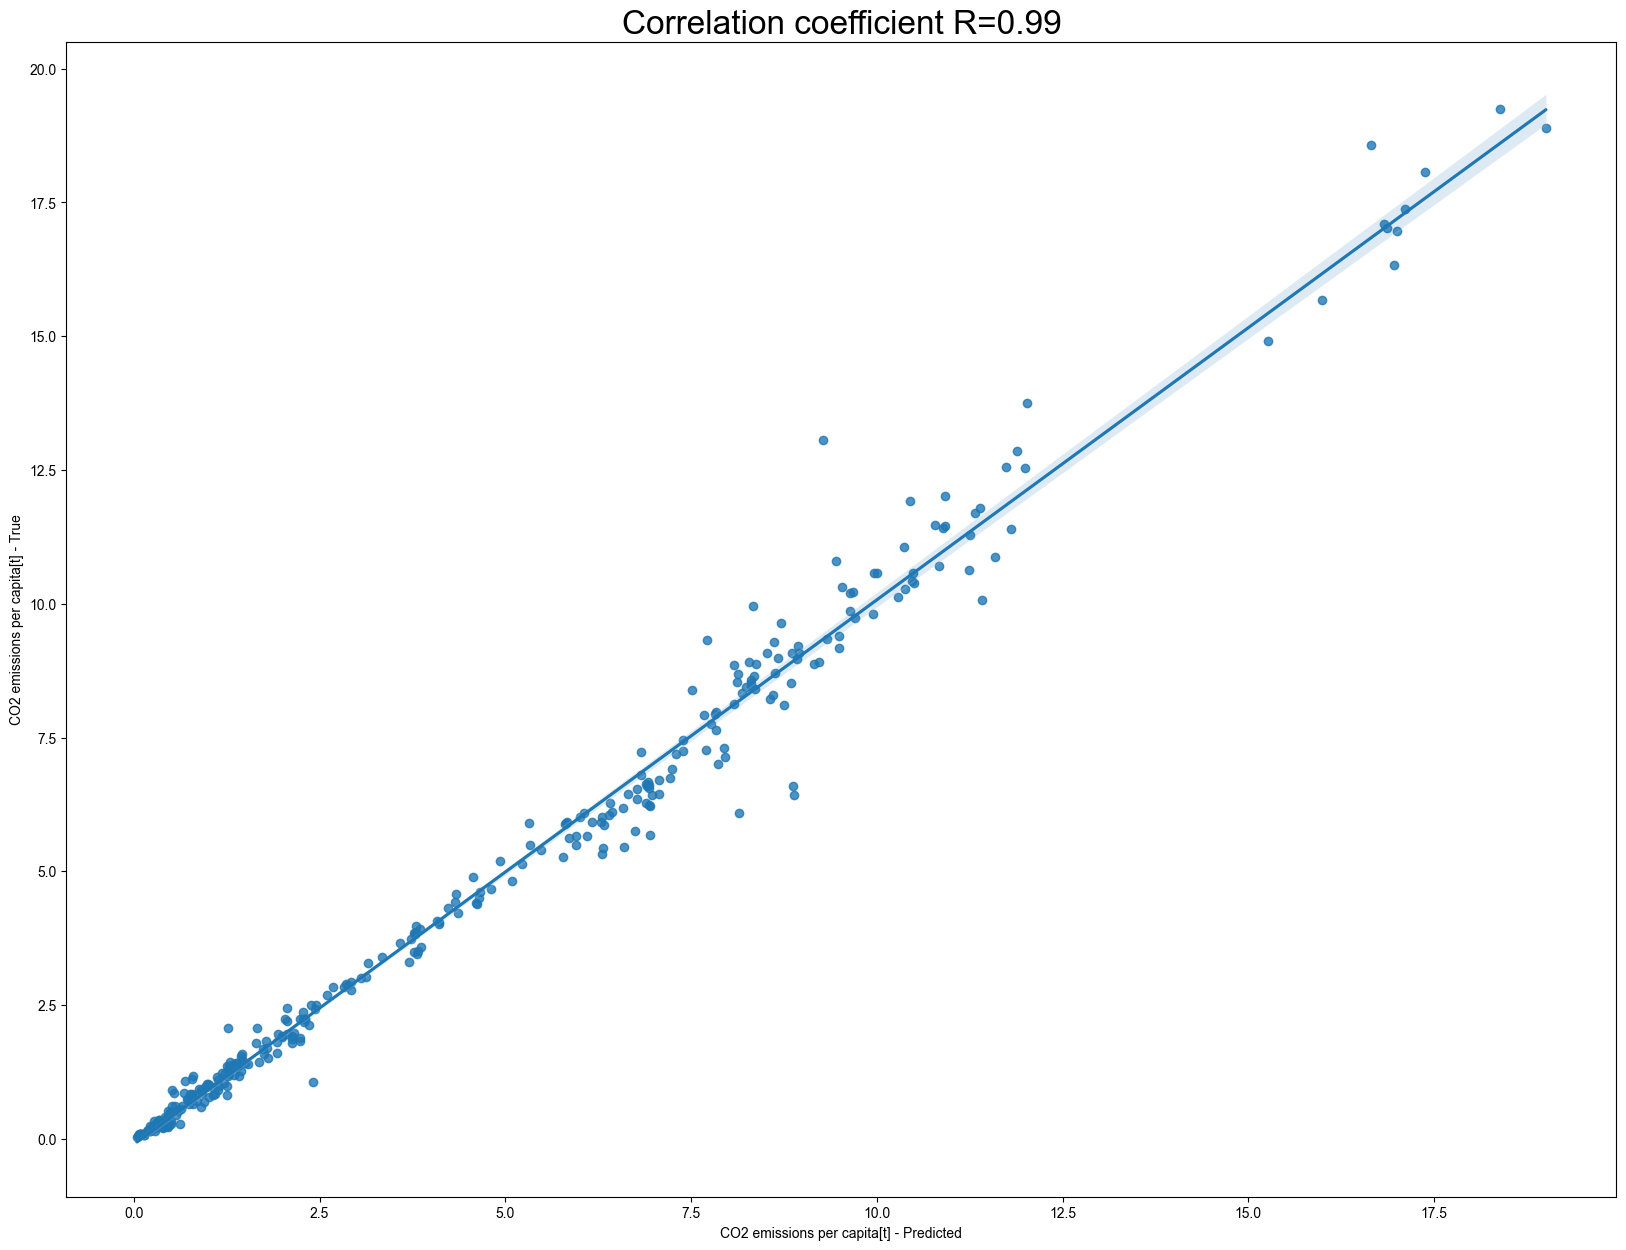

In [18]:
import seaborn as sns
# plot predictions vs true values of test subset

fig, ax = plt.subplots(figsize=(20, 15))
sns.set_theme(font_scale=2)

sns.regplot(x=predictions, y=np.transpose(label_test)[0, :], fit_reg=True, ax=ax)
plt.xlabel("CO2 emissions per capita[t] - Predicted")
plt.ylabel("CO2 emissions per capita[t] - True")
plt.title("Correlation coefficient R=" + str(round(np.corrcoef(predictions, np.transpose(label_test)[0, :])[0, 1], 2)))
plt.show()

In [19]:
import joblib
# save the model to a file
joblib.dump(rf_best_model, 'forecasting_co2_emission.pkl')
print("Model saved to 'forecasting_co2_emission.pkl'")


Model saved to 'forecasting_co2_emission.pkl'


In [20]:
# load the model from a file
loaded_model = joblib.load('forecasting_co2_emission.pkl')
print("Model loaded successfully")

Model loaded successfully


Calculating Compond Annual Growth Rate (CAGR) for key features

In [21]:
#List of selected features
selected_features = ['cereal_yield','gni_per_cap','en_per_cap',
            'pop_urb_aggl_perc','prot_area_perc','pop_growth_perc','urb_pop_growth_perc']

In [29]:
selected_countries = ['IND', 'USA', 'CHN', 'RUS', 'JPN']

# filter dataset to include only selected countries 
df_filtered = data[data['country'].isin(selected_countries)]

# Dictionary to store CAGR values
growth_rates = {}

# loop over each selected country 
for country in selected_countries:
    # Get data for the current country and sort it by year 
    country_data = data[(data['country'] == country)].sort_values('year')

    # Identify the start and end year for the country
    start_year = country_data['year'].min()
    end_year = country_data['year'].max()
    years = end_year - start_year

    # Dictionary to store growth rate of all features for current country
    country_growth = {}

    # skip this country if the time span is not valid (e.g., only one year of data)
    if years <= 0:
        print(f"skipping {country} due to insufficient year range")
        continue

    # loop through each selected feature 
    for feature in selected_features:
        # Get the feature value in start year 
        start_value = country_data[country_data['year'] == start_year][feature].values
        # Get the feature value in end year
        end_value = country_data[country_data['year'] == end_year][feature].values

        # skip if either value is missing
        if len(start_value) == 0 or len(end_value) == 0:
            continue
        # compute the Compound Annual Growth Rate (CAGR)
        cagr = (end_value[0] / start_value[0]) ** (1 / years) - 1
        # store the result in the country-specific dictionary
        country_growth[feature] = cagr
    # save the growth rates of all features for the country-specific dictionary 
    growth_rates[country] = country_growth

# To display the results
print(growth_rates)

{'IND': {'cereal_yield': np.float64(0.0194485123119712), 'gni_per_cap': np.float64(0.06852731858971195), 'en_per_cap': np.float64(0.021183029340095194), 'pop_urb_aggl_perc': np.float64(0.012552544913977837), 'prot_area_perc': np.float64(0.003543454162256099), 'pop_growth_perc': np.float64(-0.02277852673526637), 'urb_pop_growth_perc': np.float64(-0.0125559730838114)}, 'USA': {'cereal_yield': np.float64(0.022829563575152534), 'gni_per_cap': np.float64(0.04257525641890414), 'en_per_cap': np.float64(-0.0011709919656219814), 'pop_urb_aggl_perc': np.float64(0.004034853060894239), 'prot_area_perc': np.float64(0.0001271379513625437), 'pop_growth_perc': np.float64(-0.021559741500308927), 'urb_pop_growth_perc': np.float64(-0.02146546560491258)}, 'CHN': {'cereal_yield': np.float64(0.01604916213904173), 'gni_per_cap': np.float64(0.1358153996334075), 'en_per_cap': np.float64(0.04597478728959281), 'pop_urb_aggl_perc': np.float64(0.03711665520932339), 'prot_area_perc': np.float64(0.011931509868986279

C:\Users\Admin\AppData\Local\Temp\ipykernel_9916\3084946402.py:38: RuntimeWarning: invalid value encountered in scalar power
  cagr = (end_value[0] / start_value[0]) ** (1 / years) - 1


In [32]:
#Display the calculated growth  rates in the readable format
print("\nGrowth Rates (CAGR) from ():\n".format(start_year,end_year))

#loop through each country and its corresponding growth rate dictinary
for country, features in growth_rates.items():
    print(f"{country}")

    #loop through each feature and its Cagr
    for feature,rate in features.items():
        #Determine whether to display a plus or minus sign
        sign = '+' if rate >= 0 else '-'

        #print the feature name and its growth rates perc 
        print(f"-{feature}: {sign}{abs(rate * 100 ):.2f}%")

        #add a line break between countries for readability
        print()


Growth Rates (CAGR) from ():

IND
-cereal_yield: +1.94%

-gni_per_cap: +6.85%

-en_per_cap: +2.12%

-pop_urb_aggl_perc: +1.26%

-prot_area_perc: +0.35%

-pop_growth_perc: -2.28%

-urb_pop_growth_perc: -1.26%

USA
-cereal_yield: +2.28%

-gni_per_cap: +4.26%

-en_per_cap: -0.12%

-pop_urb_aggl_perc: +0.40%

-prot_area_perc: +0.01%

-pop_growth_perc: -2.16%

-urb_pop_growth_perc: -2.15%

CHN
-cereal_yield: +1.60%

-gni_per_cap: +13.58%

-en_per_cap: +4.60%

-pop_urb_aggl_perc: +3.71%

-prot_area_perc: +1.19%

-pop_growth_perc: -5.60%

-urb_pop_growth_perc: -2.79%

RUS
-cereal_yield: +1.99%

-gni_per_cap: +7.41%

-en_per_cap: -0.61%

-pop_urb_aggl_perc: +0.48%

-prot_area_perc: +0.46%

-pop_growth_perc: -nan%

-urb_pop_growth_perc: -nan%

JPN
-cereal_yield: +0.86%

-gni_per_cap: +1.84%

-en_per_cap: +0.47%

-pop_urb_aggl_perc: +0.32%

-prot_area_perc: +1.21%

-pop_growth_perc: -nan%

-urb_pop_growth_perc: -8.04%



In [33]:
#determine the range of years to forecast (next 20 years beyound the last available year)
last_year = data['year'].max()
future_years = list(range(last_year +1,last_year+21))

In [40]:
# initialize a list to store forecasted result 
forecast_results = []

# loop through each selected country for prediction 
for country in selected_countries:
    country_data = data[(data['country'] == country)].sort_values('year')
    
    # skip countries with missing feature value 
    if country_data[choosen_features].dropna().empty:
        print(f"skipping {country} due to missing value:")
        continue
    # Take the latest complete record (most recent year) for the country
    latest_row = country_data[choosen_features].dropna().iloc[-1].copy()
    
    # forecast for each year into the future
    for year in future_years:
        # Apply the previously calculated CAGR 
        for feature in choosen_features:
            growth_rate = growth_rates.get(country, {}).get(feature, 0.0)
            latest_row[feature] *= (1 + growth_rate)

        # use trained model to predict CO2 emission per capita
        input_features = latest_row.values.reshape(1, -1)
        predicted_CO2 = loaded_model.predict(input_features)[0]

        # store the forecast result
        forecast_results.append({
            'country': country,
            'year': year,
            'co2_percap': predicted_CO2
        })

n/forecasted CO2  Emission per capita(Next 20 years)


<function matplotlib.pyplot.show(close=None, block=None)>

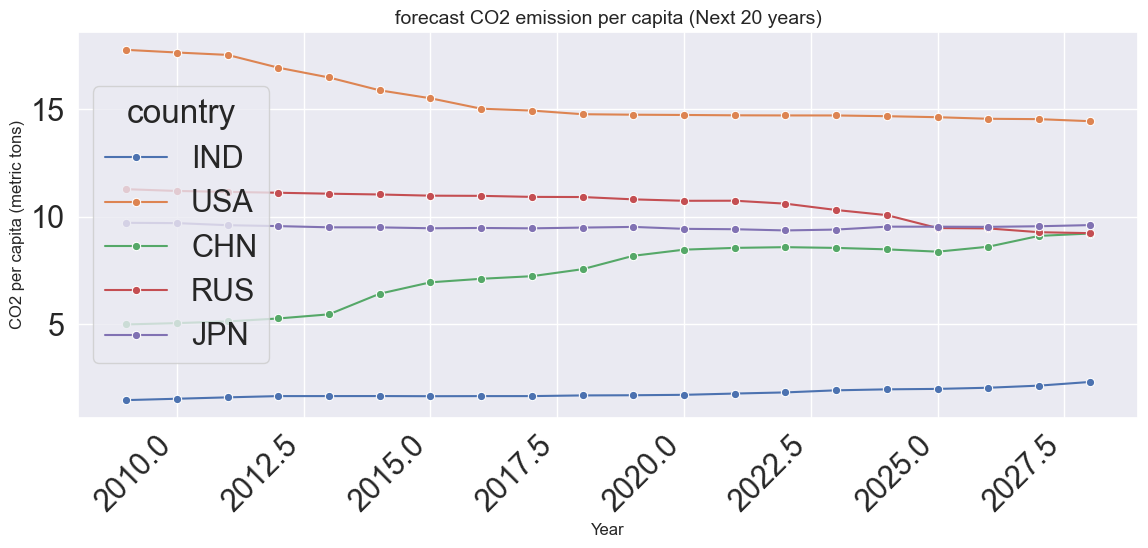

In [43]:
#convert the list of predictions into a Dataframe
df_forecast = pd.DataFrame(forecast_results)

#plot forecasted CO2, per capita for all countries over next 20 years 
print('n/forecasted CO2  Emission per capita(Next 20 years)')
plt.figure(figsize=(12,6))
sns.lineplot(data=df_forecast, x='year', y='co2_percap',hue='country',marker='o')
plt.title('forecast CO2 emission per capita (Next 20 years)',fontsize=14)
plt.xlabel('Year',fontsize=12)
plt.ylabel('CO2 per capita (metric tons)',fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show

In [44]:
# Get the last 5 years of forecast for India
india_forecast_last5 = df_forecast[(df_forecast['country'] == 'IND')].sort_values('year').tail(5)

print("Forecasted CO2 emission per capita for India (last 5 years of forecast period):")
print(india_forecast_last5[['year', 'co2_percap']])

Forecasted CO2 emission per capita for India (last 5 years of forecast period):
    year  co2_percap
15  2024    1.967152
16  2025    1.987802
17  2026    2.041773
18  2027    2.140216
19  2028    2.310267
